In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.projections.polar import PolarAxes
from pathlib import Path
import matplotlib.ticker as mtick

In [2]:
STS_df = pd.read_csv("df_3_STS_rank.csv")
STS_df = STS_df.rename(columns={"rank": "STS"})
EES_df = pd.read_csv("df_3_EES_rank.csv")
EES_df = EES_df.rename(columns={"rank": "EES"})
merged_df = pd.merge(STS_df, EES_df, on="Method")

In [3]:
method_colors = {
    'velocyto': "#6587AB",
    'scvelo_dyn': "#76B7B2",
    'scvelo_stc': "#92CB8A",
    'veloae': "#F6A24F",
    'dynamo_m1': "#DC6F71",
    'pyrovelocity_m1': "#006e54",
    'pyrovelocity_m2': "#a7e6d7",
    'unitvelo_uni': "#aa4c8f",
    'unitvelo_ind': "#E9B6DA",
    'velovae_std': "#C6A11B",
    'velovae_fullvb': "#FBEBB2",
    'kvelo': "#FAAEA0",
    'celldancer': "#7ABBEF",
    'velovi': "#A4AB47",
    'latentvelo_std': "#C4D6A0",
    'sctour_mse': "#4d5aaf",
    'sctour_nb': "#8491c3",
    'sctour_zinb': "#bbc8e6",
    'deepvelo': "#D2660D",
    'sdevelo': "#22808B",
    'svelvetvae': "#F6D55C",
    'cell2fate': "#AD2513",
    'tivelo_std': "#333631",
    'tivelo_simple': "#AFB39F",
    'graphvelo_std': "#8D6262"
}

Spearman correlation: -0.177, p-value=3.974e-01


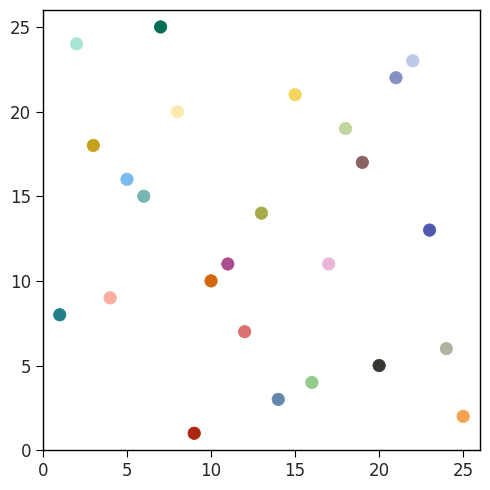

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

df3_ranked = merged_df.copy()
df3_ranked['rank_mean1'] = df3_ranked['STS']
df3_ranked['rank_mean2'] = df3_ranked['EES']

df3_ranked['class'] = df3_ranked['Method']

rho, pval = spearmanr(df3_ranked['rank_mean1'], df3_ranked['rank_mean2'])
print(f"Spearman correlation: {rho:.3f}, p-value={pval:.3e}")
plt.figure(figsize=(5, 5))
sns.set_style("white")
sns.scatterplot(
    data=df3_ranked,
    x='rank_mean1',
    y='rank_mean2',
    hue='class',
    palette=method_colors,
    s=80,
    edgecolor=None,
    linewidth=0.5,
    alpha=1.0,
    legend=False
)
plt.xlabel('', fontsize=13, labelpad=10)
plt.ylabel('', fontsize=13, labelpad=10)

lims = [
    min(df3_ranked['rank_mean1'].min(), df3_ranked['rank_mean2'].min())-1,
    max(df3_ranked['rank_mean1'].max(), df3_ranked['rank_mean2'].max())+1
]
plt.xlim(lims)
plt.ylim(lims)

x_ticks = np.arange(np.floor(lims[0]), np.ceil(lims[1]) + 1, 5)
y_ticks = np.arange(np.floor(lims[0]), np.ceil(lims[1]) + 1, 5)
plt.xticks(x_ticks, fontsize=12)
plt.yticks(y_ticks, fontsize=12)

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)


plt.tick_params(
    axis='both',
    which='both',
    direction='out',
    length=5,
    color='black',
    top=False, right=False,
    bottom = True, left=True
)

plt.tight_layout()
plt.savefig(f"rank_compare.svg", format="svg", bbox_inches="tight", dpi=300)
plt.show()

In [5]:
import scanpy as sc
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.sparse import issparse
import scvelo as scv

computing velocity graph (using 20/24 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:13) --> added 
    'cell2fate_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'cell2fate_velocity_umap', embedded velocity vectors (adata.obsm)


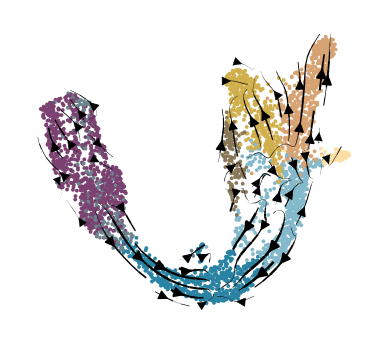

computing velocity graph (using 20/24 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'pyro_model1_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'pyro_model1_velocity_umap', embedded velocity vectors (adata.obsm)


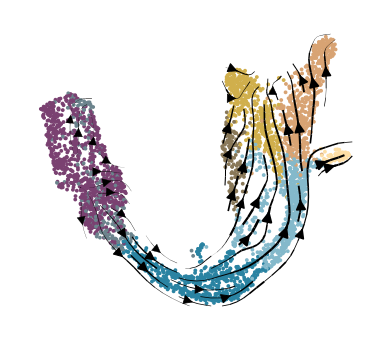

In [6]:
cluster_key = 'clusters'
dataset = 'data04'

for method in ['cell2fate','pyro_model1']:
    vkey = f"{method}_velocity"

    adata = sc.read_h5ad( Path(dataset) / f"adata_run_{method}_full.h5ad")

    all_types = adata.obs[cluster_key].unique()

    color_map = {
        'Alpha': "#d0af4c",
        'Beta':  "#d8a373",  # deep blue
        'Delta': "#fddea5",
        'Ductal':"#7a4171",  # deep red
        'Epsilon':"#897858",# rich green
        'Ngn3 high EP':"#2a83a2",  # rose
        'Ngn3 low EP':"#6c848d",  # medium gray
        'Pre-endocrine':"#84b9cb",
    }

    # 给未指定的类别统一赋值
    for ct in all_types:
        if ct not in color_map:
            color_map[ct] = "#a8a8ab"

    adata.layers[vkey] = adata.layers[vkey].astype(np.float32)
    if issparse(adata.layers[vkey]):
        adata.layers[vkey] = adata.layers[vkey].toarray().astype(np.float32)
    adata.layers[vkey] = np.where(np.isnan(adata.layers[vkey]), 0, adata.layers[vkey])

    sqrt_transform = False
    if method in ["unitvelo_ind", "unitvelo_uni"]:
        sqrt_transform = True

    scv.tl.velocity_graph(adata, vkey=vkey, sqrt_transform=sqrt_transform, n_jobs=20)

    adata.obs[cluster_key] = adata.obs[cluster_key].astype("category")
    cluster_order = adata.obs[cluster_key].cat.categories

    # 按 category 顺序生成颜色列表
    adata.uns[f'{cluster_key}_colors'] = [color_map[c] for c in cluster_order]

    # kwargs = dict(
    #     frameon=True, add_margin=.1, density=1, linewidth=1,
    #     size=30, alpha=0.6,
    # )
    kwargs = dict(
        frameon=True, 
        size=30, add_margin=.1, arrow_size=1.5, linewidth=1, alpha=1.0, density=1,
    )

    fig, ax = plt.subplots(figsize=(4, 3.5))

    scv.pl.velocity_embedding_stream(
        adata,
        color=cluster_key,
        vkey=vkey,
        basis='umap',
        title='',
        legend_loc='none',
        ax=ax,
        **kwargs,
        show=False
    )
    ax.set_title('')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{dataset}_{method}_stream.png", bbox_inches="tight", dpi=300)
    plt.show()

computing velocity graph (using 1/24 cores)


  0%|          | 0/13176 [00:00<?, ?cells/s]

    finished (0:02:37) --> added 
    'cell2fate_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:09) --> added
    'cell2fate_velocity_umap', embedded velocity vectors (adata.obsm)


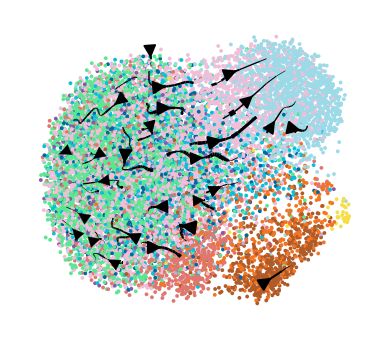

In [7]:
cluster_key = 'celltype'
dataset = 'data17'

for method in ['cell2fate']:
    vkey = f"{method}_velocity"

    adata = sc.read_h5ad( Path(dataset) / f"adata_run_{method}_0.h5ad")

    all_types = adata.obs[cluster_key].unique()

    color_map = {
    'CD8+ Cytotoxic T': "#F0BED8", 'CD8+/CD45RA+ Naive Cytotoxic': "#5CE693",
    'CD4+/CD45RO+ Memory': "#0067a4", 'CD19+ B': "#E0776F",
    'CD4+/CD25 T Reg': "#0abfdb", 'CD56+ NK': "#9ddae7",
    'CD4+ T Helper2': "#c2a9d1", 'CD4+/CD45RA+/CD25- Naive T': "#8859a5",
    'CD34+': "#f5de47", 'Dendritic': "#f37421", 'CD14+ Monocyte': "#b05a28"}

    # 给未指定的类别统一赋值
    for ct in all_types:
        if ct not in color_map:
            color_map[ct] = "#a8a8ab"

    adata.layers[vkey] = adata.layers[vkey].astype(np.float32)
    if issparse(adata.layers[vkey]):
        adata.layers[vkey] = adata.layers[vkey].toarray().astype(np.float32)
    adata.layers[vkey] = np.where(np.isnan(adata.layers[vkey]), 0, adata.layers[vkey])

    sqrt_transform = False
    if method in ["unitvelo_ind", "unitvelo_uni"]:
        sqrt_transform = True

    scv.tl.velocity_graph(adata, vkey=vkey, sqrt_transform=sqrt_transform, n_jobs=1)

    adata.obs[cluster_key] = adata.obs[cluster_key].astype("category")
    cluster_order = adata.obs[cluster_key].cat.categories

    # 按 category 顺序生成颜色列表
    adata.uns[f'{cluster_key}_colors'] = [color_map[c] for c in cluster_order]

    kwargs = dict(
        frameon=True, 
        size=30, density=0.4, add_margin=.1, arrow_size=2, linewidth=2, smooth=0.08, alpha=1.0,
    )

    fig, ax = plt.subplots(figsize=(4, 3.5))

    scv.pl.velocity_embedding_stream(
        adata,
        color=cluster_key,
        vkey=vkey,
        basis='umap',
        title='',
        legend_loc='none',
        ax=ax,
        **kwargs,
        show=False
    )
    ax.set_title('')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{dataset}_{method}_stream.png", bbox_inches="tight", dpi=300)
    plt.show()

computing velocity graph (using 1/24 cores)


  0%|          | 0/13176 [00:00<?, ?cells/s]

    finished (0:00:05) --> added 
    'pyro_model1_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'pyro_model1_velocity_umap', embedded velocity vectors (adata.obsm)


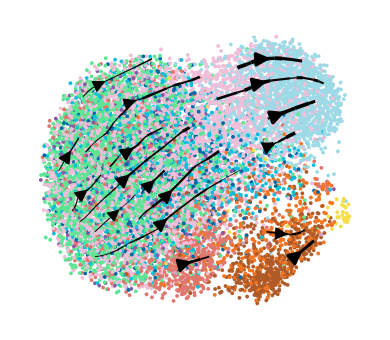

In [8]:
cluster_key = 'celltype'
dataset = 'data17'

for method in ['pyro_model1']:
    vkey = f"{method}_velocity"

    adata = sc.read_h5ad( Path(dataset) / f"adata_run_{method}_0.h5ad")

    all_types = adata.obs[cluster_key].unique()

    color_map = {
    'CD8+ Cytotoxic T': "#F0BED8", 'CD8+/CD45RA+ Naive Cytotoxic': "#5CE693",
    'CD4+/CD45RO+ Memory': "#0067a4", 'CD19+ B': "#E0776F",
    'CD4+/CD25 T Reg': "#0abfdb", 'CD56+ NK': "#9ddae7",
    'CD4+ T Helper2': "#c2a9d1", 'CD4+/CD45RA+/CD25- Naive T': "#8859a5",
    'CD34+': "#f5de47", 'Dendritic': "#f37421", 'CD14+ Monocyte': "#b05a28"}

    # 给未指定的类别统一赋值
    for ct in all_types:
        if ct not in color_map:
            color_map[ct] = "#a8a8ab"

    adata.layers[vkey] = adata.layers[vkey].astype(np.float32)
    if issparse(adata.layers[vkey]):
        adata.layers[vkey] = adata.layers[vkey].toarray().astype(np.float32)
    adata.layers[vkey] = np.where(np.isnan(adata.layers[vkey]), 0, adata.layers[vkey])

    sqrt_transform = False
    if method in ["unitvelo_ind", "unitvelo_uni"]:
        sqrt_transform = True

    scv.tl.velocity_graph(adata, vkey=vkey, sqrt_transform=sqrt_transform, n_jobs=1)

    adata.obs[cluster_key] = adata.obs[cluster_key].astype("category")
    cluster_order = adata.obs[cluster_key].cat.categories

    # 按 category 顺序生成颜色列表
    adata.uns[f'{cluster_key}_colors'] = [color_map[c] for c in cluster_order]

    kwargs = dict(
        frameon=True, 
        size=30, density=0.4, add_margin=.1, arrow_size=2, linewidth=2, smooth=0.08, alpha=1.0,
    )

    fig, ax = plt.subplots(figsize=(4, 3.5))

    scv.pl.velocity_embedding_stream(
        adata,
        color=cluster_key,
        vkey=vkey,
        basis='umap',
        title='',
        legend_loc='none',
        ax=ax,
        **kwargs,
        show=False
    )
    ax.set_title('')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{dataset}_{method}_stream.png", bbox_inches='tight', dpi=300)
    plt.show()